In [1]:
123

123

이번 단계에서는 텍스트를 제외하고 다음 컬럼만 저장.
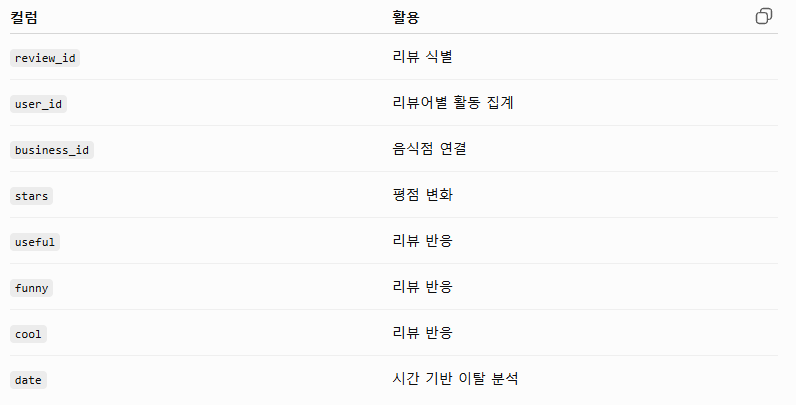


In [2]:
# 1.라이브러리
from pathlib import Path
import json

import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from tqdm.auto import tqdm

c:\Users\playdata2\SKN34-2nd-5Team\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 2. 경로 설정
# 프로젝트 최상위 폴더 탐색
current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [current_path, *current_path.parents]
        if (path / "data" / "raw").exists()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/raw 폴더를 찾을 수 없습니다."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLE_DIR.mkdir(parents=True, exist_ok=True)

REVIEW_JSON = (
    RAW_DIR
    / "yelp_academic_dataset_review.json"
)

RESTAURANT_BUSINESS_PATH = (
    INTERIM_DIR
    / "restaurant_businesses.parquet"
)

RESTAURANT_REVIEW_PATH = (
    INTERIM_DIR
    / "restaurant_reviews.parquet"
)

# 완성 전 임시 파일
TEMP_REVIEW_PATH = (
    INTERIM_DIR
    / "restaurant_reviews_building.parquet"
)

print("Review 원본:", REVIEW_JSON.exists())
print(
    "음식점 Business:",
    RESTAURANT_BUSINESS_PATH.exists()
)

Review 원본: True
음식점 Business: True


In [4]:
# 3. 음식점 ID 불러오기
restaurant_business_ids = set(
    pd.read_parquet(
        RESTAURANT_BUSINESS_PATH,
        columns=["business_id"]
    )["business_id"]
)

print(
    "음식점 업체 ID 수:",
    len(restaurant_business_ids)
)

음식점 업체 ID 수: 52268


In [5]:
# 4. 저장할 Parquet 구조 정의
review_schema = pa.schema(
    [
        ("review_id", pa.string()),
        ("user_id", pa.string()),
        ("business_id", pa.string()),
        ("stars", pa.float64()),
        ("useful", pa.int64()),
        ("funny", pa.int64()),
        ("cool", pa.int64()),
        ("date", pa.string())
    ]
)

In [6]:
# 5. 기존 파일 확인
if RESTAURANT_REVIEW_PATH.exists():
    raise FileExistsError(
        f"이미 결과 파일이 존재합니다: "
        f"{RESTAURANT_REVIEW_PATH}"
    )

if TEMP_REVIEW_PATH.exists():
    raise FileExistsError(
        "이전 실행의 임시 파일이 남아 있습니다. "
        "이전 작업이 중단됐는지 확인한 뒤 "
        "restaurant_reviews_building.parquet 파일을 "
        "직접 삭제하고 다시 실행하세요."
    )

print("새로운 음식점 리뷰 추출을 시작할 수 있습니다.")


새로운 음식점 리뷰 추출을 시작할 수 있습니다.


In [7]:
# 6. 음식점 리뷰 추출 함수
def extract_restaurant_reviews(
    review_json_path,
    output_path,
    restaurant_ids,
    schema,
    expected_rows=None,
    batch_size=50_000
):
    """
    전체 Review JSON에서 음식점 리뷰만 추출하여
    Parquet 파일로 저장한다.
    """
    writer = None
    batch = []

    total_review_rows = 0
    restaurant_review_rows = 0

    null_review_id_rows = 0
    null_user_id_rows = 0
    null_business_id_rows = 0

    unique_restaurant_users = set()

    min_review_date = None
    max_review_date = None

    try:
        with review_json_path.open(
            mode="r",
            encoding="utf-8"
        ) as file:

            for line in tqdm(
                file,
                total=expected_rows,
                desc="음식점 리뷰 추출"
            ):
                if not line.strip():
                    continue

                record = json.loads(line)
                total_review_rows += 1

                review_id = record.get("review_id")
                user_id = record.get("user_id")
                business_id = record.get(
                    "business_id"
                )
                review_date = record.get("date")

                if review_id is None or review_id == "":
                    null_review_id_rows += 1

                if user_id is None or user_id == "":
                    null_user_id_rows += 1

                if (
                    business_id is None
                    or business_id == ""
                ):
                    null_business_id_rows += 1
                    continue

                # Restaurants 업체에 작성된 리뷰만 추출
                if business_id not in restaurant_ids:
                    continue

                restaurant_review_rows += 1

                if user_id is not None and user_id != "":
                    unique_restaurant_users.add(
                        user_id
                    )

                # ISO 날짜 문자열은 문자열 비교로도
                # 최소·최대 날짜 확인 가능
                if review_date is not None:
                    if (
                        min_review_date is None
                        or review_date < min_review_date
                    ):
                        min_review_date = review_date

                    if (
                        max_review_date is None
                        or review_date > max_review_date
                    ):
                        max_review_date = review_date

                batch.append(
                    {
                        "review_id": review_id,
                        "user_id": user_id,
                        "business_id": business_id,
                        "stars": float(
                            record.get("stars", 0)
                        ),
                        "useful": int(
                            record.get("useful", 0)
                        ),
                        "funny": int(
                            record.get("funny", 0)
                        ),
                        "cool": int(
                            record.get("cool", 0)
                        ),
                        "date": review_date
                    }
                )

                # 배치가 일정 크기에 도달하면 저장
                if len(batch) >= batch_size:
                    table = pa.Table.from_pylist(
                        batch,
                        schema=schema
                    )

                    if writer is None:
                        writer = pq.ParquetWriter(
                            output_path,
                            schema=schema,
                            compression="zstd"
                        )

                    writer.write_table(table)
                    batch = []

        # 마지막 남은 데이터 저장
        if batch:
            table = pa.Table.from_pylist(
                batch,
                schema=schema
            )

            if writer is None:
                writer = pq.ParquetWriter(
                    output_path,
                    schema=schema,
                    compression="zstd"
                )

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    result = {
        "total_review_rows": total_review_rows,
        "restaurant_review_rows": (
            restaurant_review_rows
        ),
        "non_restaurant_review_rows": (
            total_review_rows
            - restaurant_review_rows
        ),
        "restaurant_review_rate_pct": round(
            restaurant_review_rows
            / total_review_rows
            * 100,
            4
        ),
        "unique_restaurant_users": len(
            unique_restaurant_users
        ),
        "null_review_id_rows": null_review_id_rows,
        "null_user_id_rows": null_user_id_rows,
        "null_business_id_rows": (
            null_business_id_rows
        ),
        "min_review_date": min_review_date,
        "max_review_date": max_review_date
    }

    return result


In [8]:
# 7. 전체 Review 추출 실행
extraction_result = extract_restaurant_reviews(
    review_json_path=REVIEW_JSON,
    output_path=TEMP_REVIEW_PATH,
    restaurant_ids=restaurant_business_ids,
    schema=review_schema,
    expected_rows=6_990_280,
    batch_size=50_000
)

extraction_result

음식점 리뷰 추출: 100%|██████████| 6990280/6990280 [01:22<00:00, 84700.55it/s] 


{'total_review_rows': 6990280,
 'restaurant_review_rows': 4724471,
 'non_restaurant_review_rows': 2265809,
 'restaurant_review_rate_pct': 67.5863,
 'unique_restaurant_users': 1445990,
 'null_review_id_rows': 0,
 'null_user_id_rows': 0,
 'null_business_id_rows': 0,
 'min_review_date': '2005-02-16 03:23:22',
 'max_review_date': '2022-01-19 19:48:25'}

In [9]:
# 8. 임시 파일 검증
parquet_file = pq.ParquetFile(
    TEMP_REVIEW_PATH
)

saved_row_count = (
    parquet_file.metadata.num_rows
)

print(
    "함수에서 집계한 음식점 리뷰:",
    extraction_result["restaurant_review_rows"]
)

print(
    "Parquet에 저장된 리뷰:",
    saved_row_count
)

print(
    "Parquet Row Group 수:",
    parquet_file.metadata.num_row_groups
)

함수에서 집계한 음식점 리뷰: 4724471
Parquet에 저장된 리뷰: 4724471
Parquet Row Group 수: 95


In [10]:
# 두 리뷰 수가 동일해야 함.
assert (
    saved_row_count
    == extraction_result[
        "restaurant_review_rows"
    ]
), "집계 행 수와 저장된 행 수가 다릅니다."

print("저장 행 수 검증 통과")

저장 행 수 검증 통과


In [11]:
# 열린 파일 연결 해제
import gc

# PyArrow가 열고 있는 Parquet 파일 닫기
try:
    parquet_file.close()
except (NameError, AttributeError):
    pass

# 객체 참조 제거
try:
    del parquet_file
except NameError:
    pass

# 사용이 끝난 객체 정리
gc.collect()

print("Parquet 파일 연결 해제 완료")

Parquet 파일 연결 해제 완료


In [12]:
# 9. 임시 파일을 최종 파일명으로 변경
# 행 수가 정상인 경우에만 파일명 확정
TEMP_REVIEW_PATH.rename(
    RESTAURANT_REVIEW_PATH
)

print(
    "최종 저장 경로:",
    RESTAURANT_REVIEW_PATH
)


최종 저장 경로: C:\Users\playdata2\SKN34-2nd-5Team\data\interim\restaurant_reviews.parquet


In [13]:
# 10. 저장된 데이터 확인

# 전체 데이터를 Pandas로 읽지 말고 앞부분만 확인해.
restaurant_review_sample_df = (
    pd.read_parquet(
        RESTAURANT_REVIEW_PATH
    )
    .head()
)

restaurant_review_sample_df

,review_id,user_id,business_id,stars,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,2015-09-23 23:10:31


In [14]:
# 현재 Parquet 크기도 확인.
restaurant_review_sample_df = (
    pd.read_parquet(
        RESTAURANT_REVIEW_PATH
    )
    .head()
)

restaurant_review_sample_df

,review_id,user_id,business_id,stars,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,2015-09-23 23:10:31


In [15]:
# pd.read_parquet(...).head()도 내부적으로 전체를 읽을 가능성이 있으니, 
# 메모리가 부족하다면 다음처럼 PyArrow로 첫 번째 묶음만 읽는 게 더 안전.
parquet_file = pq.ParquetFile(
    RESTAURANT_REVIEW_PATH
)

first_batch = next(
    parquet_file.iter_batches(
        batch_size=5
    )
)

first_batch.to_pandas()

,review_id,user_id,business_id,stars,useful,funny,cool,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,2015-09-23 23:10:31


In [16]:
# 11. 결과표 저장
extraction_summary_df = pd.DataFrame(
    [extraction_result]
)

extraction_summary_df.to_csv(
    REPORT_TABLE_DIR
    / "restaurant_review_extraction_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

extraction_summary_df

,total_review_rows,restaurant_review_rows,non_restaurant_review_rows,restaurant_review_rate_pct,unique_restaurant_users,null_review_id_rows,null_user_id_rows,null_business_id_rows,min_review_date,max_review_date
0,6990280,4724471,2265809,67.5863,1445990,0,0,0,2005-02-16 03:23:22,2022-01-19 19:48:25
